In [1]:
# Install required sentiment and preprocessing libraries (quiet mode)
!pip install vaderSentiment transformers torch emoji -q

# Import core packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji

# Import VADER sentiment analyzer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Import Hugging Face pipeline helper for sentiment inference
from transformers import pipeline

# Import warnings to suppress non-critical warnings
import warnings
warnings.filterwarnings('ignore')

# Load Spotify reviews dataset from CSV file
reviews_df = pd.read_csv("reviews.csv")

# Drop columns not needed
reviews_df = reviews_df.drop(['Time_submitted', 'Reply', 'Total_thumbsup'], axis=1)
reviews_df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 48.8 MB/s eta 0:00:00


,Review,Rating
0,"Great music service, the audio is high quality...",5
1,Please ignore previous negative rating. This a...,5
2,"This pop-up ""Get the best Spotify experience o...",4
3,Really buggy and terrible to use as of recently,1
4,Dear Spotify why do I get songs that I didn't ...,1


In [2]:
# Clean emojis from review text to standardize input to sentiment models
reviews_df['Review_cleaned'] = reviews_df['Review'].apply(
    lambda x: emoji.replace_emoji(str(x), '') if pd.notna(x) else "")

# Display dataframe to verify cleaned text column was added
reviews_df

,Review,Rating,Review_cleaned
0,"Great music service, the audio is high quality...",5,"Great music service, the audio is high quality..."
1,Please ignore previous negative rating. This a...,5,Please ignore previous negative rating. This a...
2,"This pop-up ""Get the best Spotify experience o...",4,"This pop-up ""Get the best Spotify experience o..."
3,Really buggy and terrible to use as of recently,1,Really buggy and terrible to use as of recently
4,Dear Spotify why do I get songs that I didn't ...,1,Dear Spotify why do I get songs that I didn't ...
...,...,...,...
61589,Even though it was communicated that lyrics fe...,1,Even though it was communicated that lyrics fe...
61590,"Use to be sooo good back when I had it, and wh...",1,"Use to be sooo good back when I had it, and wh..."
61591,This app would be good if not for it taking ov...,2,This app would be good if not for it taking ov...
61592,The app is good hard to navigate and won't jus...,2,The app is good hard to navigate and won't jus...


In [3]:
# Initialize VADER sentiment analyzer
vader = SentimentIntensityAnalyzer()

# Compute VADER compound score for each cleaned review
compounds = [vader.polarity_scores(t)['compound'] for t in reviews_df['Review_cleaned']]

# Store compound scores in dataframe
reviews_df['vader_compound'] = compounds

# Convert compound scores to predicted 1–5 star ratings
reviews_df['vader_predicted_rating'] = [int(round((c + 1) * 2 + 1)) for c in compounds]

# Display dataframe to verify VADER outputs were added
reviews_df

,Review,Rating,Review_cleaned,vader_compound,vader_predicted_rating
0,"Great music service, the audio is high quality...",5,"Great music service, the audio is high quality...",0.9211,5
1,Please ignore previous negative rating. This a...,5,Please ignore previous negative rating. This a...,0.6249,4
2,"This pop-up ""Get the best Spotify experience o...",4,"This pop-up ""Get the best Spotify experience o...",0.5859,4
3,Really buggy and terrible to use as of recently,1,Really buggy and terrible to use as of recently,-0.5209,2
4,Dear Spotify why do I get songs that I didn't ...,1,Dear Spotify why do I get songs that I didn't ...,0.7149,4
...,...,...,...,...,...
61589,Even though it was communicated that lyrics fe...,1,Even though it was communicated that lyrics fe...,-0.2960,2
61590,"Use to be sooo good back when I had it, and wh...",1,"Use to be sooo good back when I had it, and wh...",0.9143,5
61591,This app would be good if not for it taking ov...,2,This app would be good if not for it taking ov...,-0.9633,1
61592,The app is good hard to navigate and won't jus...,2,The app is good hard to navigate and won't jus...,0.8074,5


In [5]:
# Create Hugging Face sentiment pipeline using a star-rating BERT model
hf_pipe = pipeline("sentiment-analysis",
                   # Use multilingual star-rating model
                   model="nlptown/bert-base-multilingual-uncased-sentiment",
                   # Change to GPU
                   device=0, truncation=True, max_length=512)

# Replace empty strings with placeholder text to avoid model errors
texts = [t if t.strip() else "neutral" for t in reviews_df['Review_cleaned']]

# Initialize list to store model outputs
results = []

# Run inference in batches to improve runtime and avoid memory issues
for i in range(0, len(texts), 32):
    # Append batch predictions to results list
    results.extend(hf_pipe(texts[i:i+32]))

# Extract predicted star number from model label text and store in dataframe
reviews_df['hf_predicted_rating'] = [int(r['label'].split()[0]) for r in results]

# Display dataframe to verify Hugging Face predictions were added
reviews_df

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,Review,Rating,Review_cleaned,vader_compound,vader_predicted_rating,hf_predicted_rating
0,"Great music service, the audio is high quality...",5,"Great music service, the audio is high quality...",0.9211,5,5
1,Please ignore previous negative rating. This a...,5,Please ignore previous negative rating. This a...,0.6249,4,5
2,"This pop-up ""Get the best Spotify experience o...",4,"This pop-up ""Get the best Spotify experience o...",0.5859,4,1
3,Really buggy and terrible to use as of recently,1,Really buggy and terrible to use as of recently,-0.5209,2,1
4,Dear Spotify why do I get songs that I didn't ...,1,Dear Spotify why do I get songs that I didn't ...,0.7149,4,1
...,...,...,...,...,...,...
61589,Even though it was communicated that lyrics fe...,1,Even though it was communicated that lyrics fe...,-0.2960,2,1
61590,"Use to be sooo good back when I had it, and wh...",1,"Use to be sooo good back when I had it, and wh...",0.9143,5,1
61591,This app would be good if not for it taking ov...,2,This app would be good if not for it taking ov...,-0.9633,1,2
61592,The app is good hard to navigate and won't jus...,2,The app is good hard to navigate and won't jus...,0.8074,5,3


In [6]:
# Compute VADER exact match accuracy - percentage
vader_exact = (reviews_df['Rating'] == reviews_df['vader_predicted_rating']).mean() * 100

# Compute VADER off-by-one accuracy - percent within 1 star
vader_off1 = (abs(reviews_df['Rating'] - reviews_df['vader_predicted_rating']) <= 1).mean() * 100

# Compute VADER mean absolute error - in stars
vader_diff = abs(reviews_df['Rating'] - reviews_df['vader_predicted_rating']).mean()

# Compute Hugging Face exact match accuracy - percent
hf_exact = (reviews_df['Rating'] == reviews_df['hf_predicted_rating']).mean() * 100

# Compute Hugging Face off-by-one accuracy - percent within 1 star
hf_off1 = (abs(reviews_df['Rating'] - reviews_df['hf_predicted_rating']) <= 1).mean() * 100

# Compute Hugging Face mean absolute error - in stars
hf_diff = abs(reviews_df['Rating'] - reviews_df['hf_predicted_rating']).mean()

# Summarize both models’ performance metrics in a table
pd.DataFrame({
    'Model': ['VADER', 'HuggingFace'],
    'Exact Match %': [vader_exact, hf_exact],
    'Off-by-One %': [vader_off1, hf_off1],
    'Avg Error': [vader_diff, hf_diff]})

,Model,Exact Match %,Off-by-One %,Avg Error
0,VADER,30.972173,71.677436,1.098954
1,HuggingFace,58.572264,86.592850,0.621359


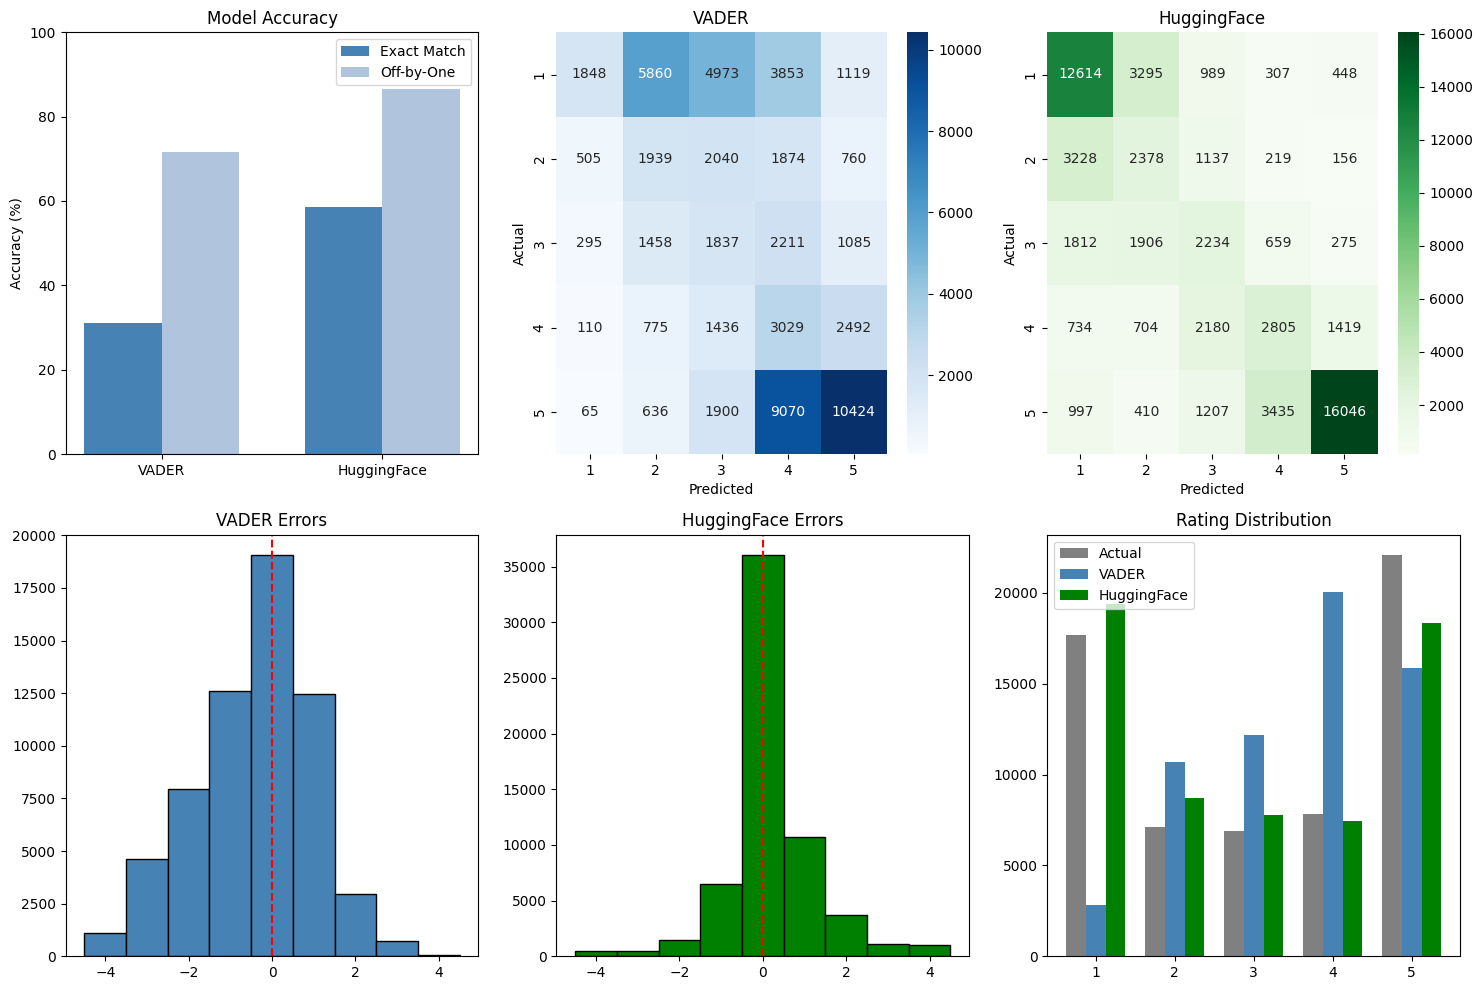

In [7]:
# Create grid for model comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# # Create side-by-side bar chart comparing model accuracy metrics
x = np.arange(2)
axes[0, 0].bar(x - 0.175, [vader_exact, hf_exact], 0.35, label='Exact Match', color='steelblue')
axes[0, 0].bar(x + 0.175, [vader_off1, hf_off1], 0.35, label='Off-by-One', color='lightsteelblue')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(['VADER', 'HuggingFace'])
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 100)

# Confusion matrices - actual vs predicted ratings
sns.heatmap(pd.crosstab(reviews_df['Rating'], reviews_df['vader_predicted_rating']),
            annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('VADER')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

sns.heatmap(pd.crosstab(reviews_df['Rating'], reviews_df['hf_predicted_rating']),
            annot=True, fmt='d', cmap='Greens', ax=axes[0, 2])
axes[0, 2].set_title('HuggingFace')
axes[0, 2].set_xlabel('Predicted')
axes[0, 2].set_ylabel('Actual')

# Show distribution of rating prediction errors for each model
axes[1, 0].hist(reviews_df['Rating'] - reviews_df['vader_predicted_rating'],
                bins=9, range=(-4.5, 4.5), color='steelblue', edgecolor='black')
axes[1, 0].set_title('VADER Errors')
axes[1, 0].axvline(0, color='red', linestyle='--')

axes[1, 1].hist(reviews_df['Rating'] - reviews_df['hf_predicted_rating'],
                bins=9, range=(-4.5, 4.5), color='green', edgecolor='black')
axes[1, 1].set_title('HuggingFace Errors')
axes[1, 1].axvline(0, color='red', linestyle='--')

# Compare actual rating distribution to model-predicted distributions
x = np.arange(1, 6)
actual = [sum(reviews_df['Rating'] == i) for i in x]
vader_pred = [sum(reviews_df['vader_predicted_rating'] == i) for i in x]
hf_pred = [sum(reviews_df['hf_predicted_rating'] == i) for i in x]
axes[1, 2].bar(x - 0.25, actual, 0.25, label='Actual', color='gray')
axes[1, 2].bar(x, vader_pred, 0.25, label='VADER', color='steelblue')
axes[1, 2].bar(x + 0.25, hf_pred, 0.25, label='HuggingFace', color='green')
axes[1, 2].set_title('Rating Distribution')
axes[1, 2].legend()

# Display plots
plt.tight_layout()
plt.show()

In [8]:
# Examples where HuggingFace is better

# Create subset dataframe with actual and predicted ratings
sample_df = reviews_df[['Review', 'Rating', 'vader_predicted_rating', 'hf_predicted_rating']].copy()

# Compute absolute prediction error for VADER
sample_df['vader_error'] = abs(sample_df['Rating'] - sample_df['vader_predicted_rating'])

# Compute absolute prediction error for Hugging Face
sample_df['hf_error'] = abs(sample_df['Rating'] - sample_df['hf_predicted_rating'])

# Display first 5 reviews where Hugging Face has lower error than VADER
sample_df[sample_df['hf_error'] < sample_df['vader_error']].head(5)

,Review,Rating,vader_predicted_rating,hf_predicted_rating,vader_error,hf_error
1,Please ignore previous negative rating. This a...,5,4,5,1,0
3,Really buggy and terrible to use as of recently,1,2,1,1,0
4,Dear Spotify why do I get songs that I didn't ...,1,4,1,3,0
6,I love the selection and the lyrics are provid...,5,4,5,1,0
9,"I'm deleting this app, for the following reaso...",1,4,1,3,0


In [9]:
# Examples where VADER is better
sample_df[sample_df['vader_error'] < sample_df['hf_error']].head(5)

,Review,Rating,vader_predicted_rating,hf_predicted_rating,vader_error,hf_error
2,"This pop-up ""Get the best Spotify experience o...",4,4,1,0,3
8,It's a great app and the best mp3 music app I ...,5,5,4,0,1
21,His voice is so sweet and hearable,4,4,5,0,1
22,I logged out on my acc but when I tried to ope...,3,3,1,0,2
24,An amazing music experience,4,4,5,0,1
